#  Introduction to Image Analysis with Python

Welcome to the "Introduction to Image Analysis with Python" notebook! In this notebook, we will learn how to work with image datasets in Python for image analysis tasks. We'll explore processing images, preparing them for machine learning algorithms, and understand common operations.

> NOTE: there are many different image file formats used in biological sciences. This notebook focuses on the commonly used [JPEG format](https://en.wikipedia.org/wiki/JPEG), in which the plant photographs in our dataset are stored.

***Before starting this notebook, make a local copy in your Google Drive by selecting File > Save a Copy in Drive.***


## Load Plant Imaging Data

In this notebook, we will be using data from the **CARA (Characterizing Arabidopsis Root Attractions)** spaceflight experiment, available through the NASA Open Science Data Repository (OSDR) as study [OSD-120](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120).

This dataset contains morphometric photographs of *Arabidopsis thaliana* (Col-0) seedling **roots** grown aboard the International Space Station. Seedlings were grown under two conditions:

- **GC (Ground Control)** - grown on the ground under matched conditions.
- **FLT (Spaceflight)** - grown in microgravity aboard the ISS.

Plants were photographed over a growth time-series (days 3, 6, 9, and 13), allowing us to study how root morphology develops over time and how it differs between spaceflight and ground control.

> Thus, when viewing the images, we can compare the shape, length, and branching of roots grown in space versus on the ground, and watch how those roots change as the seedlings grow.

More information on this dataset is available [here](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120).


In [1]:
# Install the libraries we'll use to download and process images
!pip install pillow requests scikit-image


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


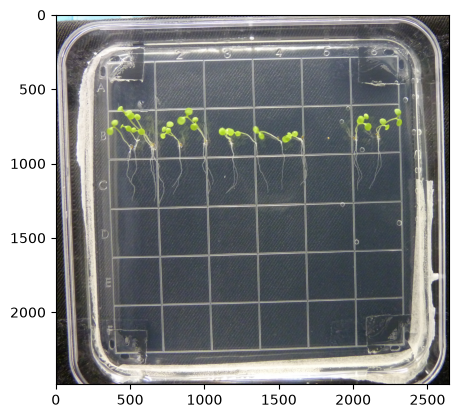

In [2]:
import requests, io
from PIL import Image
import matplotlib.pyplot as plt

# Helper function to download an image from the OSDR (OSD-120) dataset by filename
def load_osdr_image(filename):
    base = "https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/download?source=datamanager&file="
    response = requests.get(base + filename, timeout=120)
    return Image.open(io.BytesIO(response.content))

# Open a ground-control root photograph (day 13) and display it
img = load_osdr_image("LSDS-33_morphometric-photography_Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13_image1.jpg")
plt.imshow(img)

The image above shows the roots of *Arabidopsis thaliana* seedlings grown under **ground control (GC)** conditions, photographed on day 13 of growth.

You can see the fine root systems spreading out against the growth-plate background.

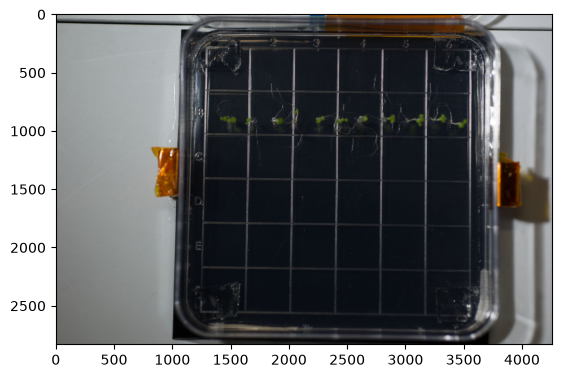

In [3]:
# Open a spaceflight root photograph (day 13) and display it
img = load_osdr_image("LSDS-33_morphometric-photography_Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13_image1.jpg")
plt.imshow(img)

This second image shows roots of seedlings grown under **spaceflight (FLT)** conditions, also photographed on day 13.

> **Challenge Question:** How does the pattern of root growth differ between the ground control (GC) and spaceflight (FLT) seedlings?

**Double-click here to enter your answer below.**

Answer:


----

## Image Preprocessing

Now that we can access the plant imaging dataset, let's explore several common techniques for preprocessing images prior to training a machine learning model. We will use two Python libraries for these tasks: [Matplotlib](https://matplotlib.org/) and [Pillow](https://pypi.org/project/pillow/).


### Image Resizing

Images can come in all sorts of sizes. Preprocessing often involves **resizing** them to a standard size that the machine learning model expects. This ensures all images are treated equally and simplifies processing for the model.

The root photographs in this dataset are very large (roughly 2600 x 2500 pixels). We'll use Pillow to open one of the root images and resize it down to a more manageable size.

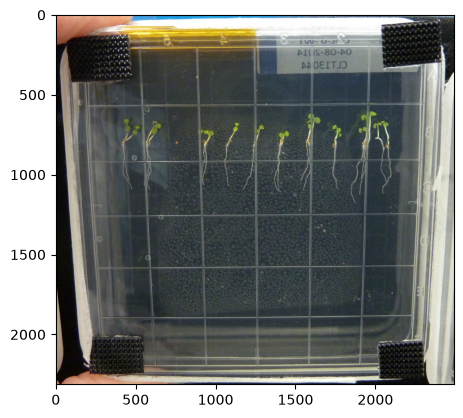

In [4]:
# First, let's view the image we want to resize (ground control, day 9)
img = load_osdr_image("LSDS-33_morphometric-photography_Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day09_image1.jpg")
plt.imshow(img)

> **CHALLENGE QUESTION:** Approximately what are the pixel dimensions of this original image? (HINT: look at the axis labels)

**Double click here to enter your answer below.**

Answer:

---

Now, let's resize that image to a specific size: 512 pixels by 512 pixels, using the `resize()` function.

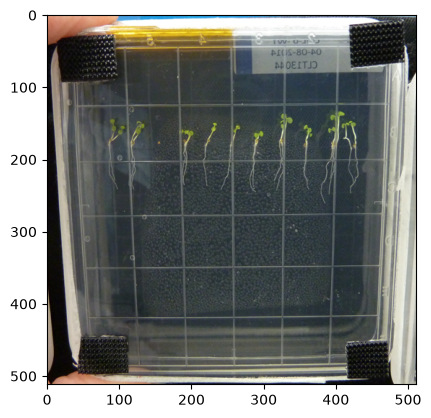

In [5]:
# Resize the image to a specific size (512x512 in this example)
resized_image = img.resize((512, 512))

# Display the resized image
plt.imshow(resized_image)

> **CHALLENGE QUESTION:** Did the resizing preserve the [aspect proportion](https://en.wikipedia.org/wiki/Aspect_ratio_(image) (relationship of width to height) of the original image, or did it stretch it in a certain dimension?

**Double click here to enter your answer below.**

Answer:

----

**Note of Caution:**

As you can see, since resizing an image has the potential to change the aspect and *stretch* the image, it is important to evaluate whether resizing is appropriate for your dataset and machine learning model.

### Normalization

The intensity values of pixels in an image can vary greatly. In machine learning, particularly when dealing with deep neural networks, image normalization is sometimes a necessary preprocessing step. It aims to standardize the pixel intensity values across an entire image dataset. This is similar to ensuring all your ingredients are measured using the same units in a recipe.

Normalization techniques adjust the pixel intensity values to a specific range, like 0 to 1 or -1 to 1. This helps the machine learning model train more efficiently.

These are 8-bit RGB photographs, so the maximum possible pixel intensity is 255. We'll use NumPy to convert an image to an array and then normalize the pixel values by dividing each element (pixel) by 255.0, effectively scaling the values between 0 and 1.

In [6]:
import numpy as np

# Convert the image to a NumPy array
image_array = np.array(img)

# Print the minimum and maximum values of the original array
print(f"Original image: Minimum pixel intensity: {image_array.min()}, Maximum pixel intensity: {image_array.max()}")

# Normalize the pixel values between 0 and 1 by dividing by the maximum possible 8-bit intensity (255)
image_norm = image_array.astype(np.float32) / 255.0

# Print the minimum and maximum values of the normalized array
print(f"Normalized image: Minimum pixel intensity: {image_norm.min()}, Maximum pixel intensity: {image_norm.max()}")

Original image: Minimum pixel intensity: 0, Maximum pixel intensity: 255
Normalized image: Minimum pixel intensity: 0.0, Maximum pixel intensity: 1.0


> **CHALLENGE QUESTIONS:** What was the minimum pixel intensity of the original image? Did the normalization bring the maximum and minimum intensity between 0 and 1?

**Double click here to enter your answers below.**

Answer:

----

**Note of Caution:**

In some bioimaging applications the *intensity* of pixels in the image is the important feature, as compared to the *shape* of features within the image. In those cases, it is important NOT to normalize or scale the pixel intensity of the image, because this process can amplify background noise and distort the biological signal. For these root photographs we are mostly interested in root *shape*, so normalization is generally safe here.


### Cropping

Images might not always be perfectly centered or oriented. **Cropping** removes irrelevant parts of the image and focuses on the region of interest.

In the code below, we'll use Pillow to define a bounding box and crop the image down to a central region containing the roots.

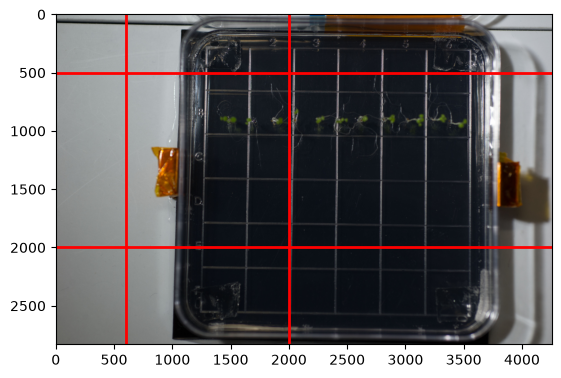

In [7]:
# Let's look at the image before we crop it (spaceflight, day 13)
img = load_osdr_image("LSDS-33_morphometric-photography_Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13_image1.jpg")

# Plot vertical lines in red to mark the left/right crop boundaries
plt.axvline(x=600, color='red', linewidth=2)
plt.axvline(x=2000, color='red', linewidth=2)

# Plot horizontal lines in red to mark the top/bottom crop boundaries
plt.axhline(y=500, color='red', linewidth=2)
plt.axhline(y=2000, color='red', linewidth=2)

plt.imshow(img)

In the image above, red lines have been drawn to capture a central region of the roots. Next, we will crop the image.

We define a **bounding box** as a tuple containing coordinates for the left, top, right, and bottom of the desired region.

We use the `crop()` function to extract the portion of the image within the specified bounding box.

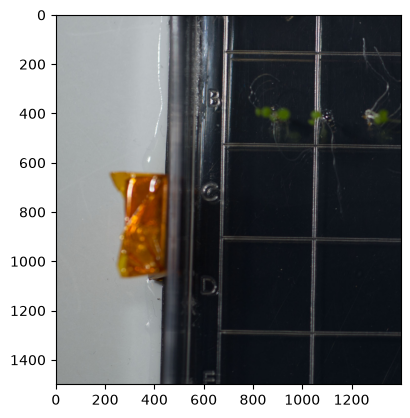

In [8]:
# Define the bounding box (left, top, right, bottom)
box = (600, 500, 2000, 2000)

# Crop the image
cropped_image = img.crop(box)

# Display the cropped image
plt.imshow(cropped_image)

----
### Rotation

 **Rotation** techniques can straighten tilted images, ensuring the objects are upright for better analysis.

 In the code below, we'll use Pillow to rotate the cropped image by a specific angle, using the `.rotate()` function which rotates the image by the specified angle (in degrees). Negative values rotate counter-clockwise.

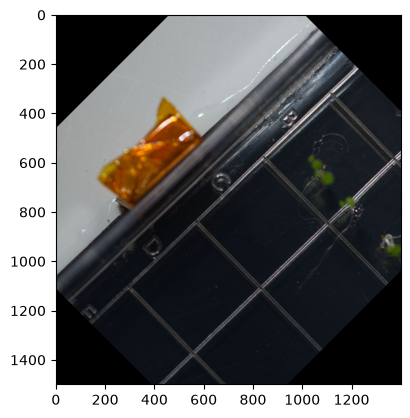

In [9]:
# Rotate the image by 45 degrees counter-clockwise
rotated_image = cropped_image.rotate(-45)

# Display the original and rotated image (optional)
plt.imshow(rotated_image)

### Image Augmentation

**Image augmentation** is a technique used in machine learning to artificially create variations of your existing training data.

Image augmentation injects variety into the training set. By introducing random transformations like rotations, flips, cropping, and brightness adjustments, the model encounters the same object from various perspectives and lighting conditions. This forces the model to focus on learning robust features that are consistent across these variations, improving its ability to generalize to new data.

Real-world images often exhibit variations due to camera angles, lighting, and environmental factors. Image augmentation helps the model become more robust to these variations. By encountering a wider range of image transformations during training, the model learns to extract the essential features of an object regardless of its pose, lighting, or background clutter. This translates to better performance on real-world data that might not perfectly match the training images.

Below, we will implement one type of augmentation, random flipping of an image.

**Random Flipping:**

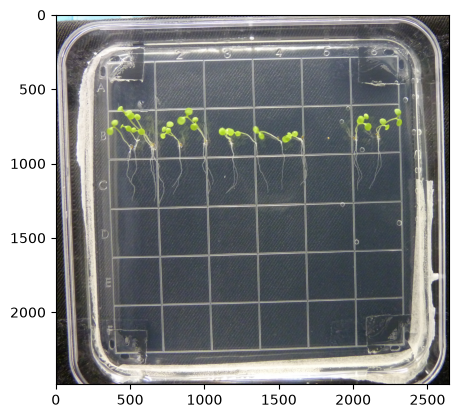

In [10]:
# Let's look at the image before we flip it (ground control, day 13)
img = load_osdr_image("LSDS-33_morphometric-photography_Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13_image1.jpg")
plt.imshow(img)

Now, let's randomly flip the image horizontally.

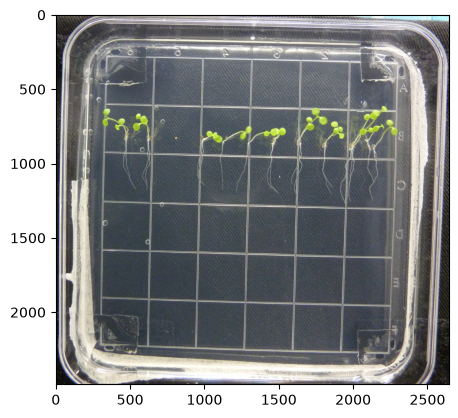

In [11]:
import random

# Randomly flip the image horizontally
image = img
if random.random() > 0.5:
    image = img.transpose(Image.FLIP_LEFT_RIGHT)

# Display the original or flipped image
plt.imshow(image)

## Image Segmentation — and why it is hard

Segmentation means partitioning an image into meaningful regions — here,
separating the **plants** from everything else (agar, grid, plate, labels, tape).
It is the gateway to *measuring* biology: area, count, growth rate.

It is also the step people most often get wrong. The tempting first move —
*"the plant is dark, the background is bright, so threshold the grayscale"* —
fails badly on real OSDR plate photos. Let's see it fail, then fix it properly.


### Attempt 1: a global grayscale threshold (this fails)

We convert to grayscale and call every pixel below 0.5 "plant".


Naive threshold labels 61% of the image as plant (a single plate of seedlings is really ~1-2%).


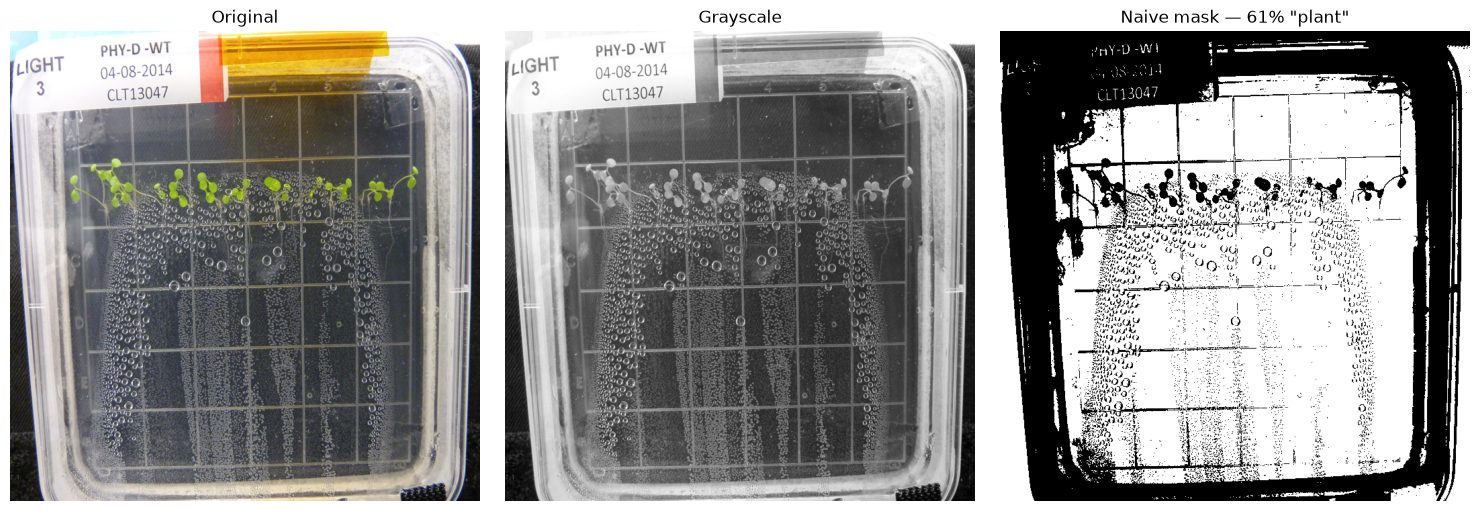

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, filters, morphology, measure

# A ground-control plate photograph (day 13)
GC13 = 'LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13_image1.jpg'
pil = load_osdr_image(GC13).convert('RGB').resize((700, 700))
image = np.array(pil)
gray = color.rgb2gray(image)

naive_mask = gray < 0.5          # 'plant = dark pixels'
print(f'Naive threshold labels {naive_mask.mean():.0%} of the image as plant '
      f'(a single plate of seedlings is really ~1-2%).')

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);       ax[0].set_title('Original')
ax[1].imshow(gray, cmap='gray'); ax[1].set_title('Grayscale')
ax[2].imshow(naive_mask, cmap='gray'); ax[2].set_title(f'Naive mask — {naive_mask.mean():.0%} "plant"')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()


The naive mask is useless: it flags most of the plate. The reason is visible in
the grayscale panel — the **background agar is dark, not bright**, and the grid,
labels and shadows sit at every brightness. Brightness alone cannot separate
*Arabidopsis* from a Petri dish. Even Otsu's automatic threshold, which assumes a
clean two-peak histogram, lands in the wrong place here.


### Attempt 2: segment by colour (this works)

The seedlings have one property the plate, grid and tape do not: they are **green**.
We combine two colour cues that together isolate living tissue —

1. the **Excess Green index**, `ExG = 2G − R − B` (bright for green pixels), and
2. a **green hue** constraint in HSV space (rejects warm-coloured tape and labels).

This is the core idea behind [PlantCV](https://plantcv.org/), the open plant-
phenotyping toolkit used throughout the
[astrobotany image-analysis repo](https://github.com/dr-richard-barker/image-analysis-software-and-R-codes).


C:\Users\drric\AppData\Local\Temp\ipykernel_16920\3942518509.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask, 60)   # drop specks
C:\Users\drric\AppData\Local\Temp\ipykernel_16920\3942518509.py:10: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = morphology.binary_closing(mask, morphology.disk(2))


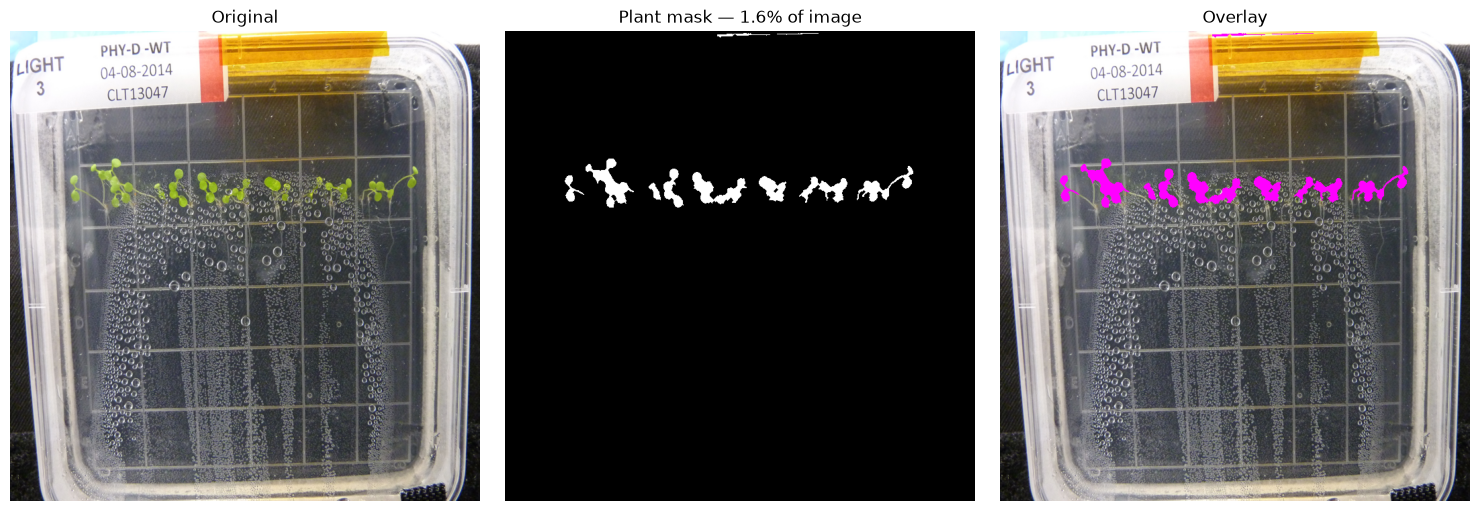

Green tissue covers 1.63% of the plate — a believable value, and the orange tape at the top is correctly ignored.


In [13]:
def segment_plants(rgb):
    """Robust green-plant mask: Excess-Green AND green-hue, then clean up."""
    arr = rgb.astype(float)
    R, G, B = arr[..., 0], arr[..., 1], arr[..., 2]
    exg = 2 * G - R - B                       # Excess Green index
    hsv = color.rgb2hsv(rgb)
    hue, sat, val = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mask = (exg > 25) & (hue > 0.16) & (hue < 0.45) & (sat > 0.20) & (val > 0.15)
    mask = morphology.remove_small_objects(mask, 60)   # drop specks
    mask = morphology.binary_closing(mask, morphology.disk(2))
    return mask

mask = segment_plants(image)
overlay = image.copy()
overlay[mask] = [255, 0, 255]      # paint detected plant magenta

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);   ax[0].set_title('Original')
ax[1].imshow(mask, cmap='gray'); ax[1].set_title(f'Plant mask — {mask.mean():.1%} of image')
ax[2].imshow(overlay); ax[2].set_title('Overlay')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()
print(f'Green tissue covers {mask.mean():.2%} of the plate — a believable value,',
      'and the orange tape at the top is correctly ignored.')


### From a mask to numbers: counting and measuring

Once we have a clean mask, `skimage.measure.label` groups connected white pixels
into distinct objects. Each object is a seedling (or a clump), and we can measure
its area, position and shape — turning a photograph into a **data table**.


Detected 9 seedling objects on this plate.


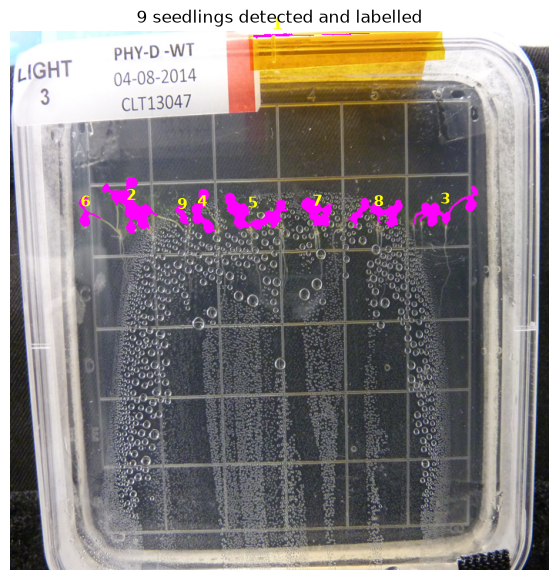

,object,area_px,row_y,col_x
0,1,189.0,5,346
1,2,1688.0,226,156
2,3,1144.0,231,564
3,4,753.0,235,249
4,5,1580.0,236,314
5,6,388.0,235,97
6,7,877.0,234,398
7,8,1092.0,234,478
8,9,223.0,238,223


In [14]:
labels = measure.label(mask)
regions = [r for r in measure.regionprops(labels) if r.area > 120]
print(f'Detected {len(regions)} seedling objects on this plate.')

import pandas as pd
tbl = pd.DataFrame({
    'object': range(1, len(regions) + 1),
    'area_px': [r.area for r in regions],
    'row_y':   [int(r.centroid[0]) for r in regions],
    'col_x':   [int(r.centroid[1]) for r in regions],
})
# annotate the overlay with object numbers
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(overlay)
for i, r in enumerate(regions, 1):
    y, x = r.centroid
    ax.text(x, y - 8, str(i), color='yellow', fontsize=11, ha='center', fontweight='bold')
ax.set_title(f'{len(regions)} seedlings detected and labelled'); ax.axis('off')
plt.show()
tbl


## Turning segmentation into science: a growth curve

A single mask is a measurement; a *series* of masks is an experiment. The CARA /
OSD-120 study photographed each plate on days 3, 6, 9 and 13, for both **ground
control (GC)** and **spaceflight (FLT)** plants, in three replicate plates each.

Applying the exact `segment_plants()` function above to all 24 photographs gives
the green shoot area on every day — a quantitative growth curve straight from the
images. (Running 24 downloads live is slow, so the pre-computed table is loaded
here; the code that produced it is the function you just saw.)


In [15]:
import json
# green shoot area (% of plate) per plate photo — produced by segment_plants()
GROWTH = json.loads("[{\"cond\": \"FLT\", \"rep\": \"1\", \"day\": 3, \"geno\": \"Col-0\", \"area_pct\": 0.3061, \"n\": 1, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day03_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"1\", \"day\": 6, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.0451, \"n\": 0, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep1_GSM2493783_Day06_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"1\", \"day\": 9, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.3451, \"n\": 7, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep1_GSM2493783_Day09_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"1\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.289, \"n\": 5, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep1_GSM2493783_Day13_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"2\", \"day\": 3, \"geno\": \"Col-0\", \"area_pct\": 0.239, \"n\": 1, \"file\": \"LSDS-33_morphometric-photography_Atha_Ws_root_FLT_Alight_Rep2_GSM2493781_Day03_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"2\", \"day\": 6, \"geno\": \"Col-0\", \"area_pct\": 0.1245, \"n\": 2, \"file\": \"LSDS-33_morphometric-photography_Atha_Ws_root_FLT_Alight_Rep2_GSM2493781_Day06_image1.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"2\", \"day\": 9, \"geno\": \"Col-0\", \"area_pct\": 0.1633, \"n\": 1, \"file\": \"LSDS-33_morphometric-photography_Atha_Ws_root_FLT_Alight_Rep2_GSM2493781_Day09_image1.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"2\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.3341, \"n\": 8, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep2_GSM2493784_Day13_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"3\", \"day\": 3, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.0, \"n\": 0, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep3_GSM2493785_Day03_image1.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"3\", \"day\": 6, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.2014, \"n\": 1, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep3_GSM2493785_Day06_image2.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"3\", \"day\": 9, \"geno\": \"Col-0\", \"area_pct\": 0.2014, \"n\": 2, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0_root_FLT_Alight_Rep3_GSM2493779_Day09_image1.jpg\"}, {\"cond\": \"FLT\", \"rep\": \"3\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.1865, \"n\": 1, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_FLT_Alight_Rep3_GSM2493785_Day13_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"1\", \"day\": 3, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.0871, \"n\": 0, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day03_image1.jpg\"}, {\"cond\": \"GC\", \"rep\": \"1\", \"day\": 6, \"geno\": \"Col-0\", \"area_pct\": 0.3498, \"n\": 6, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day06_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"1\", \"day\": 9, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.9743, \"n\": 13, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day09_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"1\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 1.6329, \"n\": 9, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13_image1.jpg\"}, {\"cond\": \"GC\", \"rep\": \"2\", \"day\": 3, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.0724, \"n\": 0, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day03_image1.jpg\"}, {\"cond\": \"GC\", \"rep\": \"2\", \"day\": 6, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.4863, \"n\": 10, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day06_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"2\", \"day\": 9, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.799, \"n\": 12, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day09_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"2\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 1.4049, \"n\": 9, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"3\", \"day\": 3, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.0292, \"n\": 0, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day03_image1.jpg\"}, {\"cond\": \"GC\", \"rep\": \"3\", \"day\": 6, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.4524, \"n\": 8, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day06_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"3\", \"day\": 9, \"geno\": \"Col-0-PhyD\", \"area_pct\": 0.7261, \"n\": 11, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day09_image2.jpg\"}, {\"cond\": \"GC\", \"rep\": \"3\", \"day\": 13, \"geno\": \"Col-0-PhyD\", \"area_pct\": 1.3008, \"n\": 10, \"file\": \"LSDS-33_morphometric-photography_Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13_image2.jpg\"}]")
g = pd.DataFrame(GROWTH)
summary = (g.groupby(['cond', 'day'])
             .agg(area_mean=('area_pct', 'mean'), area_sd=('area_pct', 'std'),
                  n_seedlings=('n', 'mean'))
             .reset_index())
summary.round(3)


,cond,day,area_mean,area_sd,n_seedlings
0,FLT,3,0.182,0.161,0.667
1,FLT,6,0.124,0.078,1.000
2,FLT,9,0.237,0.096,3.333
3,FLT,13,0.270,0.076,4.667
4,GC,3,0.063,0.030,0.000
5,GC,6,0.430,0.071,8.000
6,GC,9,0.833,0.128,12.000
7,GC,13,1.446,0.170,9.333


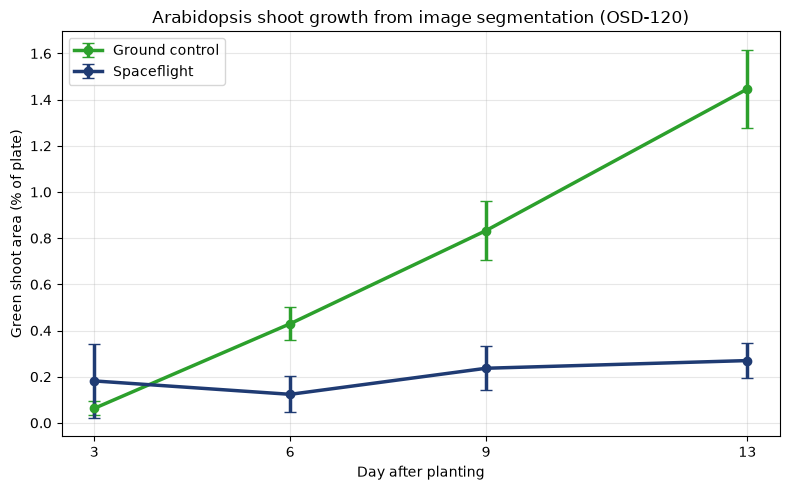

In [16]:
# Growth curve: mean green shoot area over time, GC vs FLT, with spread
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'GC': '#2ca02c', 'FLT': '#1f3b73'}
labelnm = {'GC': 'Ground control', 'FLT': 'Spaceflight'}
for cond in ['GC', 'FLT']:
    s = summary[summary['cond'] == cond].sort_values('day')
    ax.errorbar(s['day'], s['area_mean'], yerr=s['area_sd'], marker='o', capsize=4,
                lw=2.5, color=colors[cond], label=labelnm[cond])
ax.set_xlabel('Day after planting'); ax.set_ylabel('Green shoot area (% of plate)')
ax.set_title('Arabidopsis shoot growth from image segmentation (OSD-120)')
ax.set_xticks([3, 6, 9, 13]); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**The result.** Ground-control seedlings expand their green shoot area steadily
(≈0.06% → 1.4% of the plate from day 3 to 13), while the spaceflight plates stay
low and flat. A quantitative, spaceflight-vs-ground growth difference — measured
with nothing but colour segmentation and pixel counting.

> **Read this honestly.** Two caveats keep the analysis truthful:
> 
> - **Imaging is not identical** between the GC and FLT sets (different plate
>   holders, backgrounds and the flight hardware's amber tape). The green-hue mask
>   rejects those artefacts, but absolute cross-condition areas should be read as
>   *indicative*, not a calibrated measurement.
> - **Two genotypes** (Col-0 and a *phyD* line) are pooled here for a teaching
>   demo; a real analysis would separate them.
> 
> The *within-condition* growth curve (GC, day 3→13) is the clean, defensible
> signal; the cross-condition gap is consistent with the documented delay in
> spaceflight shoot development but would need matched imaging to quantify.


## Where to go next: roots, and specialised tools

Colour segmentation nails the **green shoots**, but the **roots** — thin, pale,
and the same colour as the grid — are genuinely hard, and no single threshold
solves them. This is where purpose-built tools earn their keep. The
[astrobotany image-analysis repository](https://github.com/dr-richard-barker/image-analysis-software-and-R-codes)
collects the ones used on OSDR plant imagery:

| Tool | What it does | Good for |
|------|--------------|----------|
| **[PlantCV](https://plantcv.org/)** | scriptable colour/shape phenotyping | shoot area, colour, morphology (the method above, industrial-strength) |
| **RootNav 2** | deep-learning root-system tracing → RSML | root length, architecture, skew |
| **RootTrace** | high-throughput root growth from time-lapse | primary-root elongation rate |
| **[Cellpose](https://www.cellpose.org/)** | generalist deep-learning segmentation | cells, densely packed objects |
| **Germinator** | germination scoring + curve fitting | germination timing/rate |

The lesson of this notebook: **match the method to the image.** A global grayscale
threshold is the wrong tool for a plate of seedlings; a colour model works for
shoots; and roots need a dedicated tracer. Knowing *which* to reach for — and
being honest about imaging confounds — is most of the skill in plant image analysis.


## Root tracing in practice: reading RootNav output (RSML)

The green-shoot pipeline above deliberately stopped at the shoots. The **roots**
need a dedicated tracer. RootNav (v1, semi-automatic) and **RootNav 2.0** (deep
learning, automatic) both solve this and export the open **RSML** (Root System
Markup Language) format — an XML file storing every root as a list of `(x, y)`
points.

The [image-analysis repo](https://github.com/dr-richard-barker/image-analysis-software-and-R-codes)
ships **53 real RSML traces** (the `18_way_skew` root-skew experiment: agar
buffered acid/alkaline at three concentrations × three skew-inducing tilts).
Here we read them straight from the bundled data — no tracing software needed —
and turn the geometry into root traits.


In [17]:
import xml.etree.ElementTree as ET
import pathlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RSML_DIR = pathlib.Path('data_image_analysis/rsml')
manifest = json.loads((RSML_DIR / 'manifest.json').read_text())
print(f'{len(manifest)} RSML traces bundled, spanning',
      f"{len(set((m['conc_pct'], m['buffer'], m['skew_pct']) for m in manifest.values()))} conditions.")

def parse_rsml(path):
    """Return a list of roots; each root is an (N,2) array of x,y points."""
    roots = []
    for plant in ET.parse(path).getroot().iter('plant'):
        for r in plant.iter('root'):
            poly = r.find('.//polyline')
            if poly is None:
                continue
            pts = [(float(p.get('x')), float(p.get('y'))) for p in poly.findall('point')]
            if len(pts) >= 2:
                roots.append(np.array(pts))
    return roots


53 RSML traces bundled, spanning 18 conditions.


### Visualising the traced root system

Each RSML plots as a set of polylines. We mark the seed/hypocotyl end (green) and
the root tip (red). Two conditions side by side show the tracer capturing real
architectural differences — straight roots on flat agar versus longer, wavier
roots under the skew-inducing tilt.


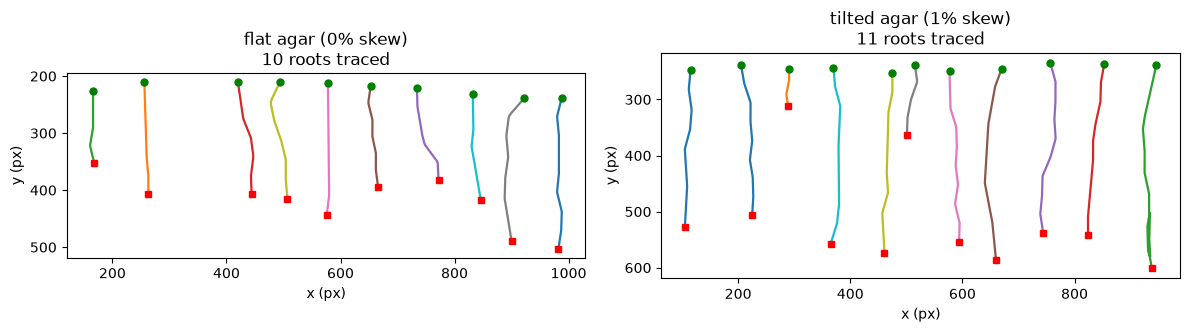

In [18]:
# pick a low-skew and a high-skew trace
def find(skew, buffer='acid', conc=1.0):
    for name, m in manifest.items():
        if m['skew_pct'] == skew and m['buffer'] == buffer and m['conc_pct'] == conc and m['rep'] == 1:
            return name
    return None

pair = [('flat agar (0% skew)', find(0.0)), ('tilted agar (1% skew)', find(1.0))]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (title, name) in zip(axes, pair):
    roots = parse_rsml(RSML_DIR / name)
    for p in roots:
        ax.plot(p[:, 0], p[:, 1], '-', lw=1.6)
        ax.plot(*p[0], 'go', ms=5)      # seed end
        ax.plot(*p[-1], 'rs', ms=5)     # tip
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_title(f'{title}\n{len(roots)} roots traced'); ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
plt.tight_layout(); plt.show()


### From geometry to root traits

With the polylines in hand, standard root-system-architecture traits are a few
lines of NumPy: **length** (summed segment distances), **depth** (vertical
extent), **horizontal spread**, and **tortuosity** (path length ÷ straight-line
distance — how wavy the root is). We compute them for all 53 traces.


In [19]:
def root_traits(roots):
    out = []
    for p in roots:
        seg = np.sqrt(np.sum(np.diff(p, axis=0) ** 2, axis=1))
        length = seg.sum()
        straight = np.sqrt(np.sum((p[-1] - p[0]) ** 2))
        out.append({
            'length_px': length,
            'depth_px': p[:, 1].max() - p[:, 1].min(),
            'horiz_px': p[:, 0].max() - p[:, 0].min(),
            'tortuosity': length / straight if straight > 0 else np.nan,
        })
    return out

records = []
for name, meta in manifest.items():
    for t in root_traits(parse_rsml(RSML_DIR / name)):
        records.append({**meta, **t, 'file': name})
roots_df = pd.DataFrame(records)
print(f'{len(roots_df)} individual roots measured across {roots_df.file.nunique()} plates.')
roots_df.groupby('skew_pct')[['length_px', 'tortuosity', 'horiz_px']].mean().round(2)


500 individual roots measured across 53 plates.


,length_px,tortuosity,horiz_px
skew_pct,,,
0.0,197.02,1.02,17.96
0.3,257.29,1.02,21.66
1.0,312.28,1.03,28.08


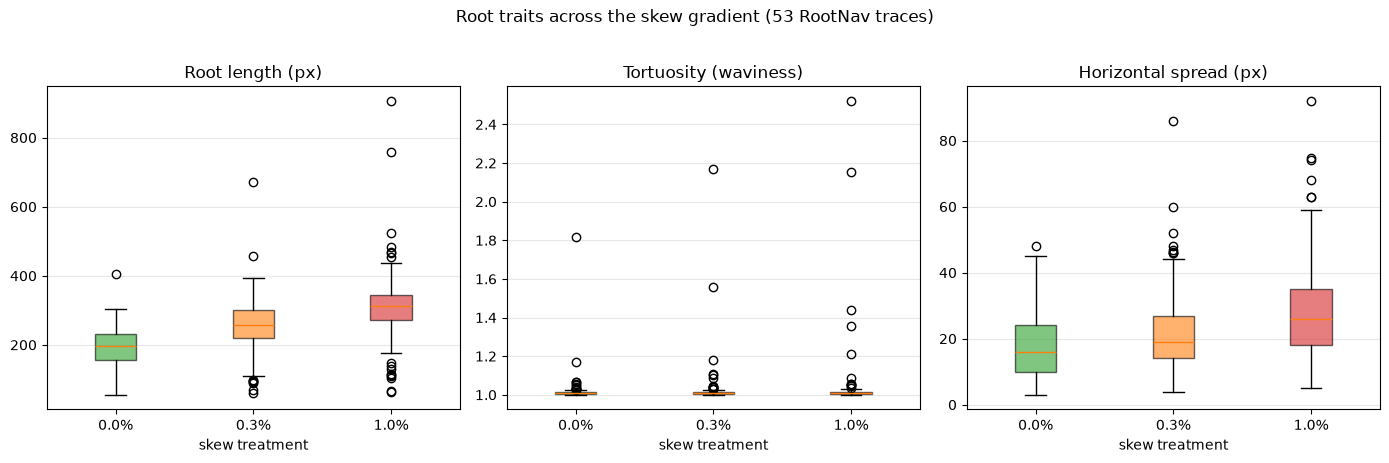

Tortuosity rises with the skew treatment — the roots wave more, exactly the phenotype RootNav's skew-measurement DLL was built to quantify.


In [20]:
# Does the skew treatment increase root waviness and lateral deviation?
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
skew_levels = sorted(roots_df['skew_pct'].unique())
for ax, (col, ttl) in zip(axes, [('length_px', 'Root length (px)'),
                                 ('tortuosity', 'Tortuosity (waviness)'),
                                 ('horiz_px', 'Horizontal spread (px)')]):
    data = [roots_df[roots_df['skew_pct'] == s][col].values for s in skew_levels]
    bp = ax.boxplot(data, tick_labels=[f'{s}%' for s in skew_levels], patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#2ca02c', '#ff7f0e', '#d62728']):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_title(ttl); ax.set_xlabel('skew treatment'); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Root traits across the skew gradient (53 RootNav traces)', y=1.02)
plt.tight_layout(); plt.show()
print('Tortuosity rises with the skew treatment — the roots wave more, exactly the',
      'phenotype RootNav\'s skew-measurement DLL was built to quantify.')


## Preparing OSDR plate photos for RootNav 2.0

RootNav 2.0 is fully automatic, but its deep network works best on **few,
well-separated plants on a clean background** (Yasrab et al. 2019). A raw OSDR
plate photo — nine seedlings in a row, a printed grid, plate walls and flight
tape — is the opposite of that. So before tracing we **prepare** the image:

1. **locate** each seedling (reuse the green-shoot segmentation from earlier),
2. **tile** the plate into one vertical strip per seedling (shoot on top, root
   hanging below), giving RootNav 2.0 the single-plant inputs it prefers, and
3. **enhance root contrast** with CLAHE so the pale roots stand out from the agar.


In [21]:
from skimage import exposure

# A plate photo with clearly visible roots on dark agar
PREP_IMG = 'LSDS-33_morphometric-photography_Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13_image1.jpg'
big = load_osdr_image(PREP_IMG).convert('RGB')
W, H = big.size
big_arr = np.array(big)

# 1. locate seedlings on a downscaled copy (segment_plants defined earlier)
small = big.resize((800, 800))
sm_mask = segment_plants(np.array(small))
sm_lbl = measure.label(sm_mask)
cx_list = sorted((r.centroid[1] * W / 800, r.centroid[0] * H / 800)
                 for r in measure.regionprops(sm_lbl) if r.area > 150)
# merge shoots closer than 5% of width into one column
cols = []
for cx, cy in cx_list:
    if cols and cx - cols[-1][0] < 0.05 * W:
        continue
    cols.append((cx, cy))
print(f'{len(cols)} seedling columns located for tiling.')


9 seedling columns located for tiling.


C:\Users\drric\AppData\Local\Temp\ipykernel_16920\3942518509.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask, 60)   # drop specks
C:\Users\drric\AppData\Local\Temp\ipykernel_16920\3942518509.py:10: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = morphology.binary_closing(mask, morphology.disk(2))


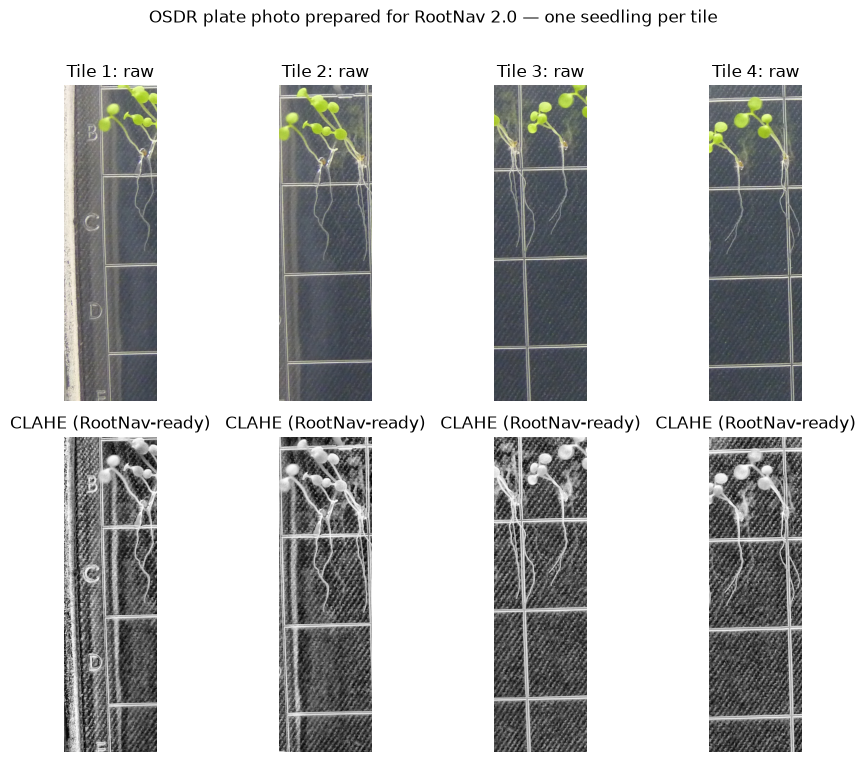

In [22]:
# 2 + 3. tile around each seedling and enhance root contrast
def prepare_tile(cx, cy, tile_frac=0.13, up=0.05, down=0.42):
    x0, x1 = int(max(0, cx - tile_frac * W / 2)), int(min(W, cx + tile_frac * W / 2))
    y0, y1 = int(max(0, cy - up * H)), int(min(H, cy + down * H))
    rgb = big_arr[y0:y1, x0:x1]
    gray = color.rgb2gray(rgb)
    enhanced = exposure.equalize_adapthist(gray, clip_limit=0.02)   # CLAHE
    return rgb, enhanced

tiles = [prepare_tile(cx, cy) for cx, cy in cols]

n = min(4, len(tiles))
fig, axes = plt.subplots(2, n, figsize=(n * 2.4, 7.5))
for i in range(n):
    axes[0, i].imshow(tiles[i][0]); axes[0, i].set_title(f'Tile {i+1}: raw'); axes[0, i].axis('off')
    axes[1, i].imshow(tiles[i][1], cmap='gray'); axes[1, i].set_title('CLAHE (RootNav-ready)'); axes[1, i].axis('off')
fig.suptitle('OSDR plate photo prepared for RootNav 2.0 — one seedling per tile', y=1.01)
plt.tight_layout(); plt.show()


Each tile now holds a single root system, with the pale root clearly separated
from the dark agar — the input RootNav 2.0 is designed for. In a real pipeline
you would **save** these tiles to disk and point RootNav 2.0 at the folder:

```python
from PIL import Image
out = pathlib.Path('rootnav_input'); out.mkdir(exist_ok=True)
for i, (rgb, _) in enumerate(tiles, 1):
    Image.fromarray(rgb).save(out / f'{PREP_IMG[:-4]}_seedling{i:02d}.png')
# then, in the RootNav 2.0 environment:
#   python predict.py --model arabidopsis_plate ./rootnav_input ./rootnav_output
```

RootNav 2.0 writes one RSML per tile — which loops straight back to the parser at
the top of this section, closing the circle from **raw plate photo → prepared
tiles → automatic tracing → RSML → root traits**.

> **Honest caveats.** The printed grid lines survive CLAHE and can be mistraced as
> lateral roots; a production pipeline adds grid suppression (e.g. a tuned
> frequency-domain or morphological filter) and a scale bar for pixel→mm
> calibration. RootNav 2.0's *Arabidopsis* model may also need fine-tuning on
> flight-hardware imagery. Preparation reduces the problem; it does not erase the
> reason root phenotyping stays hard.
